In [85]:
import pandas as pd # Analisis de datos
import numpy as np #  Calculo Numerico
import matplotlib.pyplot as plt # Creacion de grafico

# Cargar el dataset
df = pd.read_csv("Sales Data.csv")

In [86]:
# Mostrar las primeras 5 filas para confirmar que se cargó correctamente
df.head()

,Unnamed: 0,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Sales,City,Hour
0,0,295665,Macbook Pro Laptop,1,1700.00,2019-12-30 00:01:00,"136 Church St, New York City, NY 10001",12,1700.00,New York City,0
1,1,295666,LG Washing Machine,1,600.00,2019-12-29 07:03:00,"562 2nd St, New York City, NY 10001",12,600.00,New York City,7
2,2,295667,USB-C Charging Cable,1,11.95,2019-12-12 18:21:00,"277 Main St, New York City, NY 10001",12,11.95,New York City,18
3,3,295668,27in FHD Monitor,1,149.99,2019-12-22 15:13:00,"410 6th St, San Francisco, CA 94016",12,149.99,San Francisco,15
4,4,295669,USB-C Charging Cable,1,11.95,2019-12-18 12:38:00,"43 Hill St, Atlanta, GA 30301",12,11.95,Atlanta,12


In [87]:
print(df.columns)

Index(['Unnamed: 0', 'Order ID', 'Product', 'Quantity Ordered', 'Price Each',
       'Order Date', 'Purchase Address', 'Month', 'Sales', 'City', 'Hour'],
      dtype='object')


In [88]:
df.rename(columns={
    'Unnamed: 0': 'Indice',
    'Order ID': 'ID de Pedido',
    'Product': 'Producto',
    'Quantity Ordered': 'Cantidad de Productos',
    'Price Each': 'Precio Unitario',
    'Order Date': 'Fecha del Pedido',
    'Purchase Address': 'Dirección de Compra',
    'Month': 'Mes',
    'Sales': 'Total Ventas',
    'City': 'Ciudad',
    'Hour': 'Hora'
}, inplace=True)

In [89]:
print(df.columns)



Index(['Indice', 'ID de Pedido', 'Producto', 'Cantidad de Productos',
       'Precio Unitario', 'Fecha del Pedido', 'Dirección de Compra', 'Mes',
       'Total Ventas', 'Ciudad', 'Hora'],
      dtype='object')


In [90]:
print(df.isnull().sum())  # Revisa cuántos valores faltan en cada columna


Indice                   0
ID de Pedido             0
Producto                 0
Cantidad de Productos    0
Precio Unitario          0
Fecha del Pedido         0
Dirección de Compra      0
Mes                      0
Total Ventas             0
Ciudad                   0
Hora                     0
dtype: int64


In [91]:
#  Inspeccionar la estructura y los datos de un DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185950 entries, 0 to 185949
Data columns (total 11 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Indice                 185950 non-null  int64  
 1   ID de Pedido           185950 non-null  int64  
 2   Producto               185950 non-null  object 
 3   Cantidad de Productos  185950 non-null  int64  
 4   Precio Unitario        185950 non-null  float64
 5   Fecha del Pedido       185950 non-null  object 
 6   Dirección de Compra    185950 non-null  object 
 7   Mes                    185950 non-null  int64  
 8   Total Ventas           185950 non-null  float64
 9   Ciudad                 185950 non-null  object 
 10  Hora                   185950 non-null  int64  
dtypes: float64(2), int64(5), object(4)
memory usage: 15.6+ MB


In [92]:
# Descripción de las columnas
df.describe()

,Indice,ID de Pedido,Cantidad de Productos,Precio Unitario,Mes,Total Ventas,Hora
count,185950.000000,185950.000000,185950.000000,185950.000000,185950.000000,185950.000000,185950.000000
mean,8340.388475,230417.569379,1.124383,184.399735,7.059140,185.490917,14.413305
std,5450.554093,51512.737110,0.442793,332.731330,3.502996,332.919771,5.423416
min,0.000000,141234.000000,1.000000,2.990000,1.000000,2.990000,0.000000
25%,3894.000000,185831.250000,1.000000,11.950000,4.000000,11.950000,11.000000
50%,7786.000000,230367.500000,1.000000,14.950000,7.000000,14.950000,15.000000
75%,11872.000000,275035.750000,1.000000,150.000000,10.000000,150.000000,19.000000
max,25116.000000,319670.000000,9.000000,1700.000000,12.000000,3400.000000,23.000000


In [93]:
# Conversión de Fechas
df['Fecha del Pedido'] = pd.to_datetime(df['Fecha del Pedido'], errors='coerce')
df['Mes'] = df['Fecha del Pedido'].dt.month
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185950 entries, 0 to 185949
Data columns (total 11 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   Indice                 185950 non-null  int64         
 1   ID de Pedido           185950 non-null  int64         
 2   Producto               185950 non-null  object        
 3   Cantidad de Productos  185950 non-null  int64         
 4   Precio Unitario        185950 non-null  float64       
 5   Fecha del Pedido       185950 non-null  datetime64[ns]
 6   Dirección de Compra    185950 non-null  object        
 7   Mes                    185950 non-null  int32         
 8   Total Ventas           185950 non-null  float64       
 9   Ciudad                 185950 non-null  object        
 10  Hora                   185950 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int32(1), int64(4), object(3)
memory usage: 14.9+ MB


In [94]:
df['Total Ventas'] = df['Total Ventas'].astype('int64')

In [95]:
df['Precio Unitario'] = df['Precio Unitario'].astype('int64')

In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185950 entries, 0 to 185949
Data columns (total 11 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   Indice                 185950 non-null  int64         
 1   ID de Pedido           185950 non-null  int64         
 2   Producto               185950 non-null  object        
 3   Cantidad de Productos  185950 non-null  int64         
 4   Precio Unitario        185950 non-null  int64         
 5   Fecha del Pedido       185950 non-null  datetime64[ns]
 6   Dirección de Compra    185950 non-null  object        
 7   Mes                    185950 non-null  int32         
 8   Total Ventas           185950 non-null  int64         
 9   Ciudad                 185950 non-null  object        
 10  Hora                   185950 non-null  int64         
dtypes: datetime64[ns](1), int32(1), int64(6), object(3)
memory usage: 14.9+ MB


In [97]:
df.shape # Ver las filas y columnas

(185950, 11)

In [98]:
df.duplicated().sum() # Mostrar datos duplicados

np.int64(0)

In [99]:
df.isna().sum() # Mostrar datos nulos

,0
Indice,0
ID de Pedido,0
Producto,0
Cantidad de Productos,0
Precio Unitario,0
Fecha del Pedido,0
Dirección de Compra,0
Mes,0
Total Ventas,0
Ciudad,0


In [100]:
# Contar valores únicos por columna
df.nunique()


,0
Indice,25093
ID de Pedido,178437
Producto,19
Cantidad de Productos,9
Precio Unitario,16
Fecha del Pedido,142395
Dirección de Compra,140787
Mes,12
Total Ventas,42
Ciudad,9


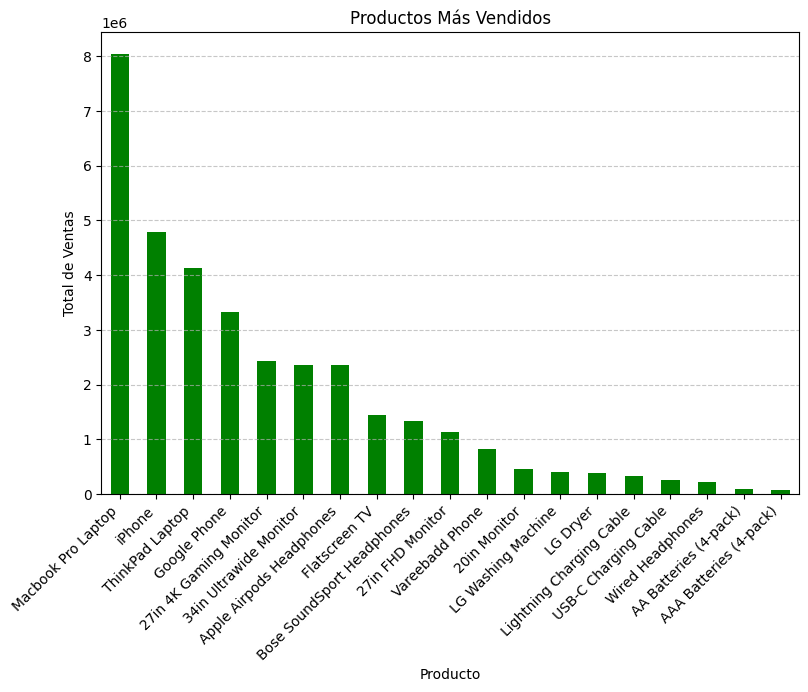

In [101]:
import matplotlib.pyplot as plt

# Agrupar ventas por producto
ventas_por_producto = df.groupby('Producto')['Total Ventas'].sum().sort_values(ascending=False)

# Crear el gráfico de barras
plt.figure(figsize=(9,6))
ventas_por_producto.plot(kind='bar', color='green')

# Personalizar el gráfico
plt.title('Productos Más Vendidos')
plt.xlabel('Producto')
plt.ylabel('Total de Ventas')
plt.xticks(rotation=45, ha='right')  # Rotar etiquetas si son muchas
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Mostrar el gráfico
plt.show()


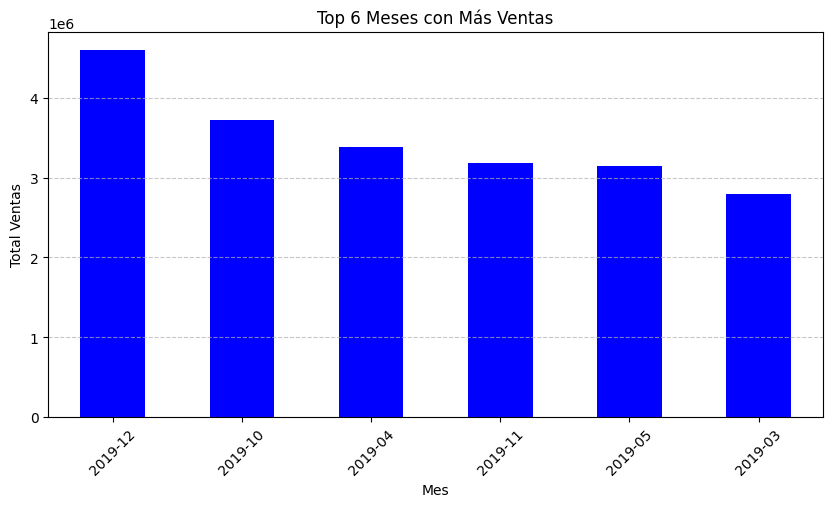

In [102]:
import pandas as pd
import matplotlib.pyplot as plt

# Verificar si 'Fecha del Pedido' y 'Total Ventas' existen
if 'Fecha del Pedido' in df.columns and 'Total Ventas' in df.columns:
    # Extraer el mes y agrupar por mes
    df['Mes'] = df['Fecha del Pedido'].dt.to_period('M')  # Convierte a formato Año-Mes
    ventas_por_mes = df.groupby('Mes')['Total Ventas'].sum().sort_values(ascending=False)  # Ordenar de mayor a menor

    # 📊 Graficar los 6 meses con más ventas
    plt.figure(figsize=(10, 5))
    ventas_por_mes.head(6).plot(kind='bar', color='b')
    plt.xlabel("Mes")
    plt.ylabel("Total Ventas")
    plt.title("Top 6 Meses con Más Ventas")
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
else:
    print()



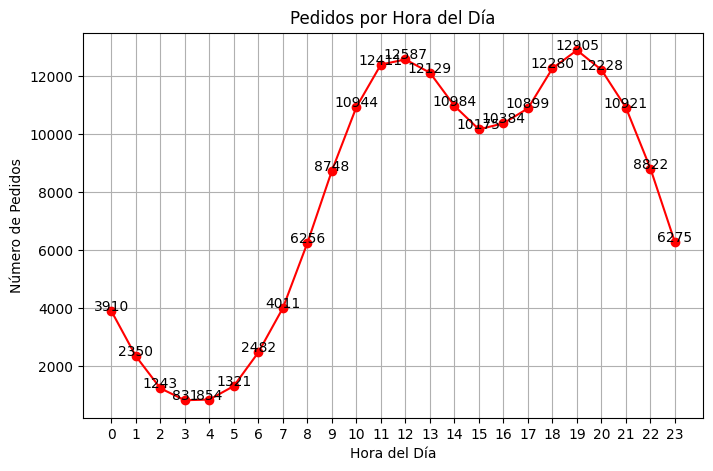

In [103]:
# Agrupar por hora
compras_por_hora = df.groupby('Hora')['ID de Pedido'].count()

plt.figure(figsize=(8, 5))
plt.plot(compras_por_hora.index, compras_por_hora.values, marker='o', linestyle='-', color='red')

# Agregar etiquetas de valores en cada punto
for i, v in zip(compras_por_hora.index, compras_por_hora.values):
    plt.text(i, v + 5, str(v), ha='center', fontsize=10, color='black')

plt.xlabel("Hora del Día")
plt.ylabel("Número de Pedidos")
plt.title("Pedidos por Hora del Día")
plt.xticks(range(0, 24))  # Mostrar todas las horas
plt.grid(True)
plt.show()


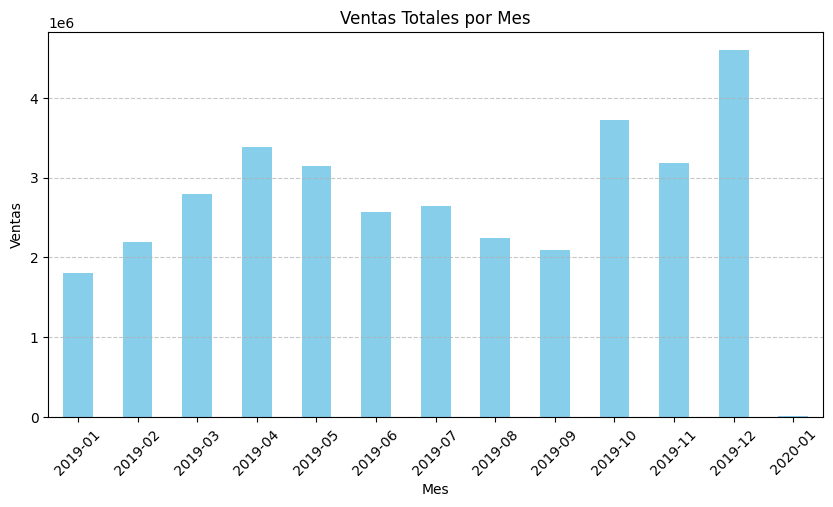

In [104]:
# Agrupar datos por mes y calcular las ventas totales
ventas_por_mes = df.groupby('Mes')['Total Ventas'].sum()

# Crear el gráfico
plt.figure(figsize=(10, 5))
ventas_por_mes.plot(kind='bar', color='skyblue')

# Personalizar el gráfico
plt.title('Ventas Totales por Mes')
plt.xlabel('Mes')
plt.ylabel('Ventas')
plt.xticks(rotation=45)  # Rotar etiquetas si es necesario
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Mostrar el gráfico
plt.show()


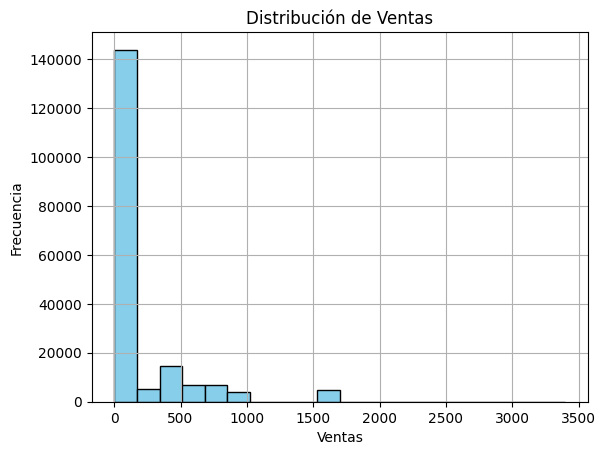

Total de Productos Vendidos: 209079


In [105]:
# Total de productos vendidos
total_productos = df["Cantidad de Productos"].sum()
# 1. Histograma de ventas
df["Total Ventas"].hist(bins=20, color='skyblue', edgecolor='black')
plt.xlabel("Ventas")
plt.ylabel("Frecuencia")
plt.title("Distribución de Ventas")
plt.show()
print(f"Total de Productos Vendidos: {total_productos}")

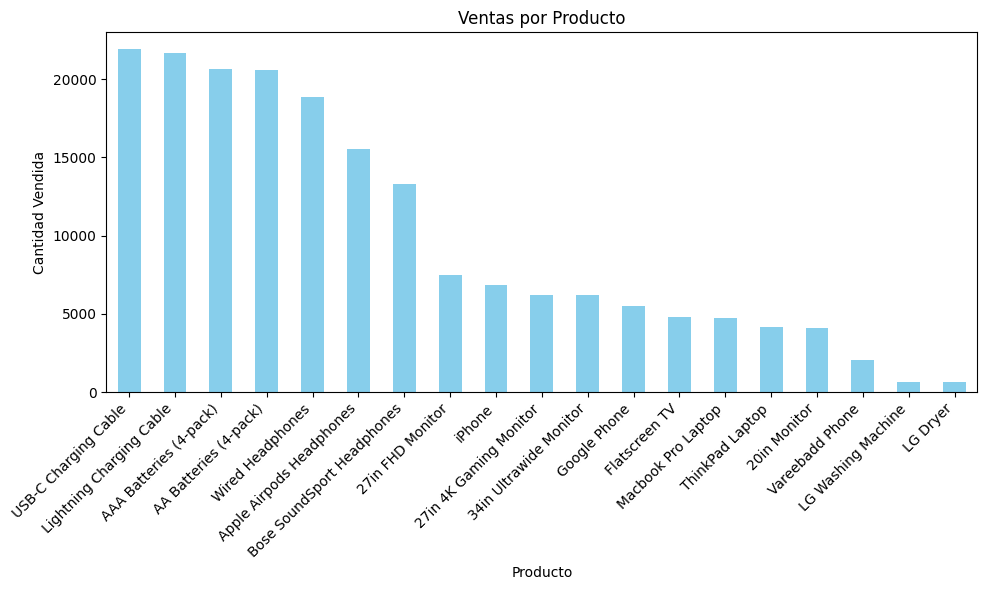

In [106]:
# Producto más vendido
producto_mas_vendido = df["Producto"].value_counts().idxmax()
cantidad_producto_mas_vendido = df["Producto"].value_counts().max()

# Crear gráfico de barras para visualizar la distribución de ventas por producto
producto_ventas = df["Producto"].value_counts()

# Crear la gráfica
plt.figure(figsize=(10, 6))
producto_ventas.plot(kind='bar', color='skyblue')
plt.title('Ventas por Producto')
plt.xlabel('Producto')
plt.ylabel('Cantidad Vendida')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Mostrar el gráfico
plt.show()


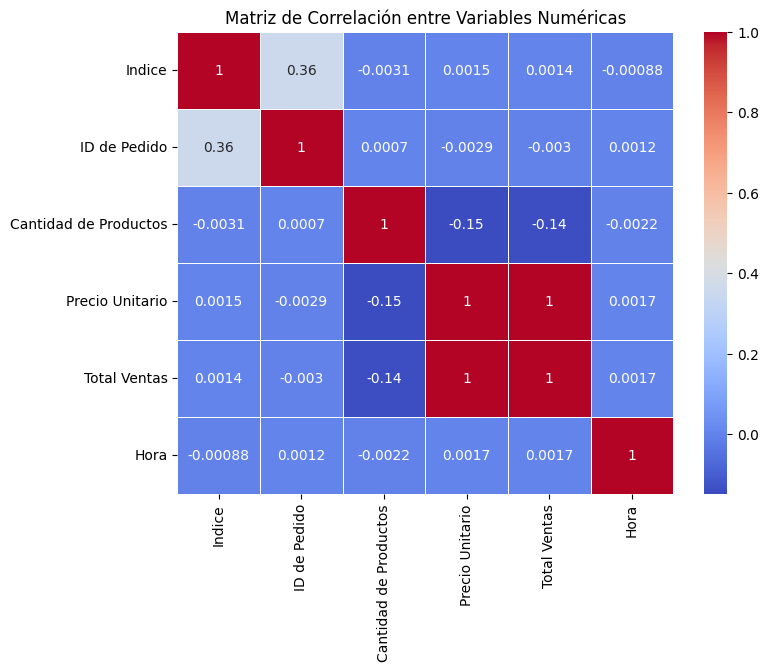

In [107]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionar solo columnas numéricas
df_numerico = df.select_dtypes(include=['number'])

plt.figure(figsize=(8, 6))
sns.heatmap(df_numerico.corr(), annot=True, cmap='coolwarm', linewidths=0.5)

# Título del gráfico
plt.title("Matriz de Correlación entre Variables Numéricas")

plt.show()
# 🔴 Cercano a 1 → Correlación positiva fuerte (cuando una variable sube, la otra también).
# 🔵 Cercano a 1 → Correlación negativa fuerte (cuando una variable sube, la otra baja).
# ⚪ Cercano a 0 → No hay relación entre las variables.

<ipython-input-108-37bb03f59087>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Ciudad', order=df['Ciudad'].value_counts().index, palette="coolwarm")


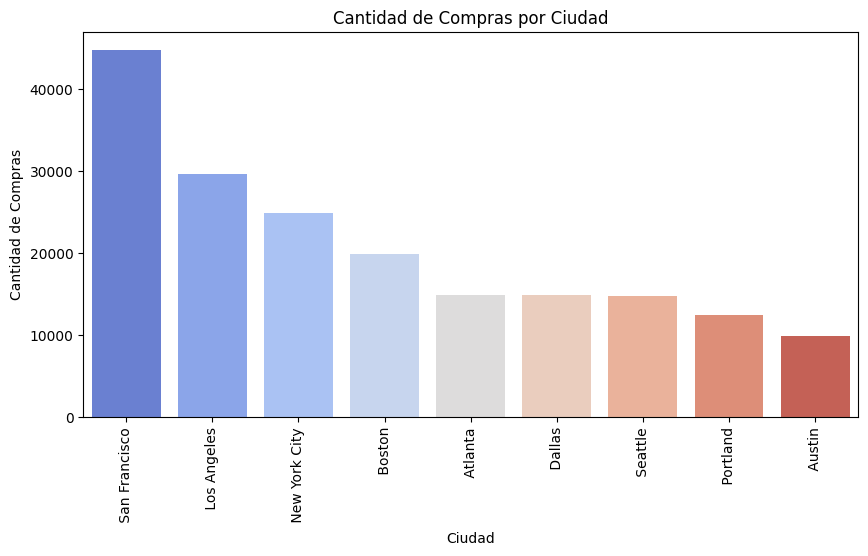

In [108]:
# Cantidad de Compras por Ciudad
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.countplot(data=df, x='Ciudad', order=df['Ciudad'].value_counts().index, palette="coolwarm")
plt.xticks(rotation=90)
plt.xlabel("Ciudad")
plt.ylabel("Cantidad de Compras")
plt.title("Cantidad de Compras por Ciudad")
plt.show()


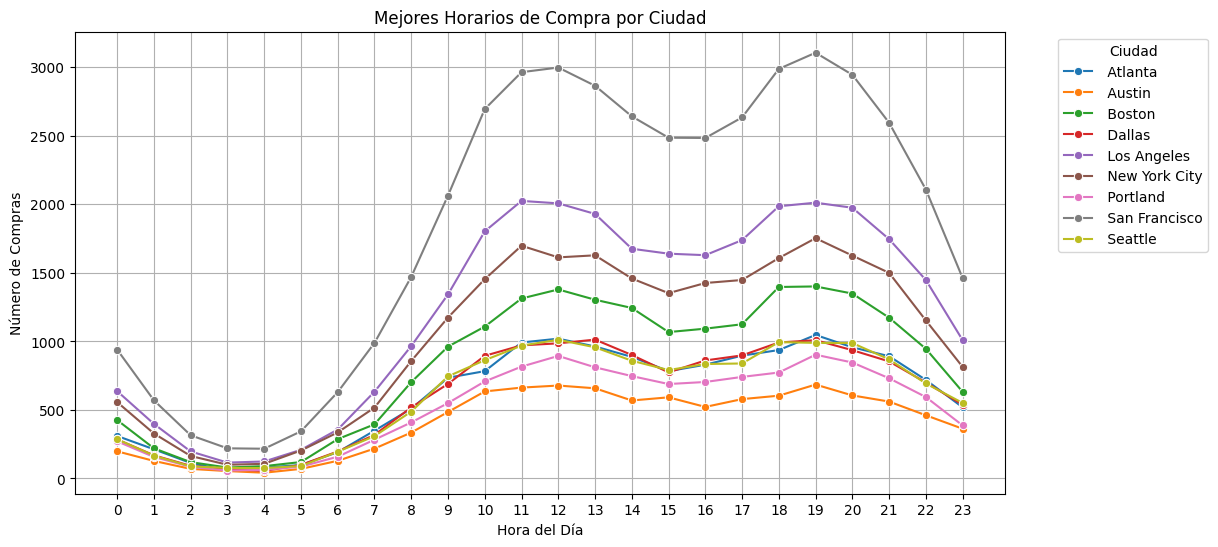

In [109]:
# Compras por ciudad y por hora
compras_ciudad_hora = df.groupby(['Ciudad', 'Hora'])['ID de Pedido'].count().reset_index()

# Crear gráfico de líneas
plt.figure(figsize=(12, 6))
sns.lineplot(data=compras_ciudad_hora, x='Hora', y='ID de Pedido', hue='Ciudad', marker="o")

plt.xlabel("Hora del Día")
plt.ylabel("Número de Compras")
plt.title("Mejores Horarios de Compra por Ciudad")
plt.xticks(range(0, 24))  # Mostrar todas las horas
plt.legend(title="Ciudad", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()



In [110]:
df.to_csv('data.csv', index=False)
from google.colab import files
files.download('data.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>